In [ ]:
#@title Install qiskit
# Install qiskit and qiskit-aer if you haven't already
!pip install qiskit qiskit-aer
!pip install pylatexenc
!pip install matplotlib



#@title pip install
#!pip install qiskit qiskit-aer
#!pip install pylatexenc
#!pip install matplotlib

In [ ]:
#@title Simplest Version 1 Trine Implementation
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np

def trine_naimark_circuit():
    """
    Implements Trine POVM via Naimark dilation
    """
    # System qubit (q0) and ancilla qubit (q1)
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)

    # Prepare initial state on q0 (example: |+> state)
    #qc.h(0)

    qc.barrier([0])
    qc.barrier([0])
    qc.barrier([0, 1])

    # Naimark dilation unitary
    # This maps computational basis to the dilated measurement basis
    qc.h(1)              # Put ancilla in |+>
    qc.cx(0, 1)          # Create entanglement
    qc.rz(2*np.pi/3, 0)  # Rotate system qubit
    qc.cx(0, 1)          # More entanglement
    qc.h(1)              # Transform to measurement basis

    # Measure both qubits projectively
    #qc.measure_all()  # Measure all qubits
    qc.barrier([0, 1])
    qc.measure(0, 0)
    qc.measure(1, 1)

    return qc

# Show the circuit
qc = trine_naimark_circuit()
#print(qc.draw("mpl"))
qc.draw("mpl")

In [ ]:
#@title Simplest Version 2 Trine Implementation
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np

def trine_naimark_circuit():
    """
    Implements Trine POVM via Naimark dilation
    """
    # System qubit (q0) and ancilla qubit (q1)
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr)

    # Prepare initial state on q0 (example: |+> state)
    #qc.h(0)

    qc.barrier([0])
    qc.barrier([0])
    qc.barrier([0, 1])

    # Naimark dilation unitary
    # This maps computational basis to the dilated measurement basis
    qc.h(1)              # Put ancilla in |+>
    qc.cry(1.231, 0, 1)  # Rotate system qubit
    qc.h(0)          # More entanglement
    qc.cx(0, 1)          # More entanglement
    qc.h(0)          # More entanglement

    # Measure both qubits projectively
    #qc.measure_all()  # Measure all qubits
    qc.barrier([0, 1])
    qc.measure(0, 0)
    qc.measure(1, 1)

    return qc

# Show the circuit
qc = trine_naimark_circuit()
#print(qc.draw("mpl"))
qc.draw("mpl")

In [ ]:
#@title The First Trine Implementation - original
import numpy as np
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import matplotlib.pyplot as plt

def trine_measurement(qubit_state='0'):
    """
    Perform Trine measurement on a single qubit.

    The Trine POVM consists of three measurement operators:
    E0 = (2/3)|ψ0><ψ0|, where |ψ0> = |0>
    E1 = (2/3)|ψ1><ψ1|, where |ψ1> = (-1/2)|0> + (√3/2)|1>
    E2 = (2/3)|ψ2><ψ2|, where |ψ2> = (-1/2)|0> - (√3/2)|1>
    """

    # Create quantum and classical registers
    qr = QuantumRegister(1, 'q')
    qr2 = QuantumRegister(1, 'q2')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, qr2, cr)

    # Initialize the qubit in the desired state
    if qubit_state == '0':
        # |0> state (already initialized)
        pass
    elif qubit_state == '1':
        # |1> state
        qc.x(0)
    elif qubit_state == '+':
        # |+> state
        qc.h(0)
    elif qubit_state == '-':
        # |-> state
        qc.x(0)
        qc.h(0)
    elif qubit_state == 'i':
        # |i> state = (|0> + i|1>)/√2
        qc.h(0)
        qc.s(0)
    else:
        raise ValueError("State must be '0', '1', '+', '-', or 'i'")

    # Implement Trine measurement using Naimark dilation
    # This maps computational basis to the Trine POVM elements
    qc.h(qr2[0])
    qc.cx(qr[0], qr2[0])
    qc.rz(2*np.pi/3, qr[0])
    qc.cx(qr[0], qr2[0])
    qc.h(qr2[0])

    # Measure both qubits
    qc.measure(qr[0], cr[0])
    qc.measure(qr2[0], cr[1])

    return qc

def analyze_trine_results(counts):
    """
    Analyze the measurement results and map to Trine outcomes.
    """
    total_shots = sum(counts.values())

    # Map the 2-bit outcomes to Trine measurement results
    # 00 -> E0, 10 -> E1, 01 -> E2
    trine_outcomes = {
        'E0': counts.get('00', 0),
        'E1': counts.get('10', 0),
        'E2': counts.get('01', 0)
    }

    # Calculate probabilities
    probabilities = {k: v/total_shots for k, v in trine_outcomes.items()}

    return trine_outcomes, probabilities

def calculate_theoretical_probabilities(state):
    """Calculate theoretical probabilities for Trine measurement."""
    if state == '0':
        return {'E0': 2/3, 'E1': 1/6, 'E2': 1/6}
    elif state == '1':
        return {'E0': 0, 'E1': 0.5, 'E2': 0.5}
    elif state == '+':
        return {'E0': 1/3, 'E1': 1/3, 'E2': 1/3}
    elif state == '-':
        return {'E0': 1/3, 'E1': 1/3, 'E2': 1/3}
    elif state == 'i':
        # |i> = (|0> + i|1>)/√2
        return {'E0': 1/3, 'E1': (2 + np.sqrt(3))/6, 'E2': (2 - np.sqrt(3))/6}
    else:
        return None

def run_circuit(qc, shots=8192):
    """Run a quantum circuit using AerSimulator (Qiskit 1.x compatible)."""
    # Create simulator
    simulator = AerSimulator()

    # Compile the circuit for the simulator
    from qiskit import transpile
    compiled_circuit = transpile(qc, simulator)

    # Run the job
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()

    return result.get_counts()

def main():
    # Test Trine measurement on different initial states
    print("Trine Measurement Demo (Qiskit 1.x - AerSimulator)")
    print("=" * 70)

    # Test on different initial states
    test_states = ['0', '1', '+', '-', 'i']

    for state in test_states:
        print(f"\n{'='*70}")
        print(f"Initial state: |{state}>")
        print(f"{'='*70}")

        # Create the circuit
        qc = trine_measurement(state)

        # Run the circuit
        counts = run_circuit(qc, shots=8192)

        # Analyze results
        outcomes, probabilities = analyze_trine_results(counts)

        # Get theoretical probabilities
        theoretical = calculate_theoretical_probabilities(state)

        # Display results
        print("\nMeasurement outcomes:")
        print(f"{'Outcome':<10} {'Counts':<10} {'Experimental':<15} {'Theoretical':<15} {'Difference':<10}")
        print(f"{'-'*70}")

        for outcome in ['E0', 'E1', 'E2']:
            exp_prob = probabilities[outcome]
            theo_prob = theoretical[outcome]
            diff = exp_prob - theo_prob
            print(f"{outcome:<10} {outcomes[outcome]:<10} {exp_prob:.4f}{' ':<8} {theo_prob:.4f}{' ':<8} {diff:+.4f}")

        # Calculate error metrics
        tvd = 0.5 * sum(abs(probabilities[outcome] - theoretical[outcome]) for outcome in ['E0', 'E1', 'E2'])
        rmse = np.sqrt(np.mean([(probabilities[o]-theoretical[o])**2 for o in ['E0','E1','E2']]))

        print(f"\nTotal Variation Distance: {tvd:.4f}")
        print(f"RMS Error: {rmse:.4f}")

        # Print the circuit for the first state
        if state == '0':
            print("\nCircuit diagram:")
            print(qc.draw())

def simple_trine_demo():
    """A very simple demo that just shows the Trine measurement working."""
    print("\n" + "="*70)
    print("SIMPLE TRINE DEMO")
    print("="*70)

    # Create a simple circuit for |+> state
    qc = QuantumCircuit(2, 2)

    # Initialize in |+> state on qubit 0
    qc.h(0)

    # Trine measurement circuit
    qc.h(1)
    qc.cx(0, 1)
    qc.rz(2*np.pi/3, 0)
    qc.cx(0, 1)
    qc.h(1)

    # Measure
    qc.measure(0, 0)
    qc.measure(1, 1)

    # Run
    counts = run_circuit(qc, shots=4096)

    # Display raw results
    print("\nRaw measurement counts:")
    for outcome in ['00', '01', '10', '11']:
        count = counts.get(outcome, 0)
        print(f"  |{outcome}⟩: {count:4d} ({count/4096:.3f})")

    # Map to Trine outcomes
    e0 = counts.get('00', 0) / 4096
    e1 = counts.get('10', 0) / 4096
    e2 = counts.get('01', 0) / 4096

    print("\nTrine POVM outcomes (|+⟩ state):")
    print(f"  E0: {e0:.4f} (theoretical: 0.3333)")
    print(f"  E1: {e1:.4f} (theoretical: 0.3333)")
    print(f"  E2: {e2:.4f} (theoretical: 0.3333)")

def mathematical_explanation():
    """Pure mathematical explanation of Trine POVM without quantum circuits."""
    print("\n" + "="*70)
    print("MATHEMATICAL EXPLANATION OF TRINE POVM")
    print("="*70)

    print("\nThe Trine POVM consists of three operators:")
    print("  E0 = (2/3)|0⟩⟨0|")
    print("  E1 = (2/3)|ψ₁⟩⟨ψ₁|, where |ψ₁⟩ = -½|0⟩ + (√3/2)|1⟩")
    print("  E2 = (2/3)|ψ₂⟩⟨ψ₂|, where |ψ₂⟩ = -½|0⟩ - (√3/2)|1⟩")

    print("\nThese operators satisfy:")
    print("  E0 + E1 + E2 = I")
    print("  Tr(Ei) = 2/3 for all i")

    print("\nFor a state |ψ⟩, the probability of outcome i is ⟨ψ|Ei|ψ⟩")
    print("\nExamples:")
    print("  For |0⟩: P(E0)=2/3, P(E1)=1/6, P(E2)=1/6")
    print("  For |1⟩: P(E0)=0, P(E1)=1/2, P(E2)=1/2")
    print("  For |+⟩: P(E0)=1/3, P(E1)=1/3, P(E2)=1/3")

if __name__ == "__main__":
    main()
    simple_trine_demo()
    print ("NNNNaya")
    mathematical_explanation()

Trine POVM Simulation using Qiskit

Demonstrating POVM Property
Sum of POVM elements (should be identity):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

POVM completeness relation holds: True
Testing Trine POVM implementation

Input state: |0⟩
********
[1.+0.j 0.+0.j]
****************
Outcome  Theoretical  Simulated    Difference  
--------------------------------------------
E0       0.6667       0.4929       0.1738      
E1       0.1667       0.5071       0.3404      
E2       0.1667       0.0000       0.1667      

Input state: |1⟩
********
[0.+0.j 1.+0.j]
****************
Outcome  Theoretical  Simulated    Difference  
--------------------------------------------
E0       0.0000       0.4998       0.4998      
E1       0.5000       0.1664       0.3336      
E2       0.5000       0.3338       0.1662      

Input state: |+⟩
********
[0.70710678+0.j 0.70710678+0.j]
****************
Outcome  Theoretical  Simulated    Difference  
--------------------------------------------
E0       0.3333      

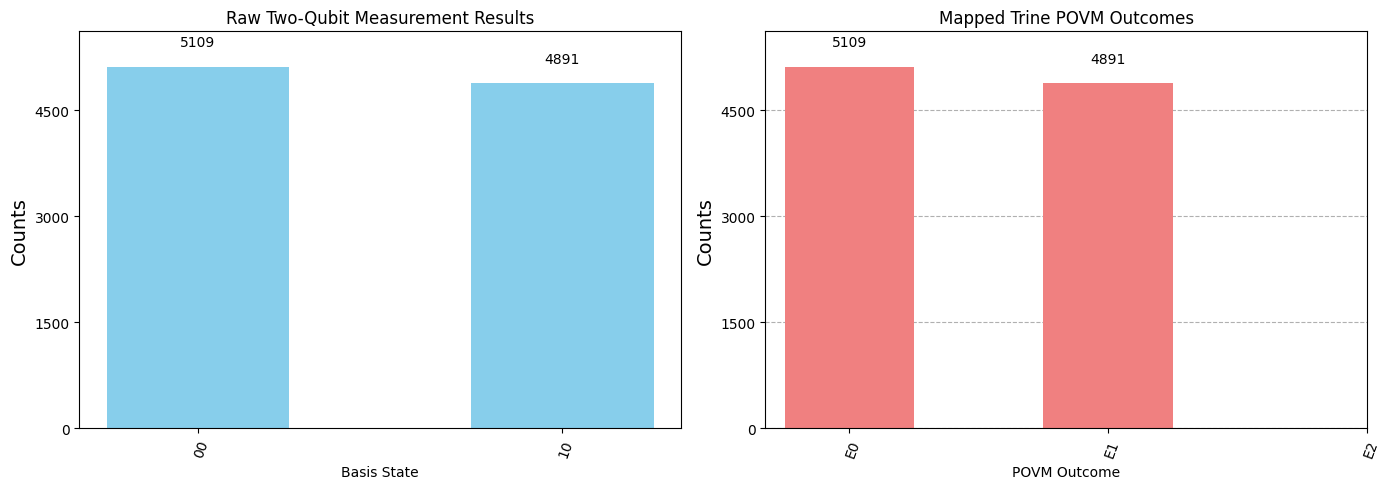


Simulation complete!


In [ ]:
#@title Second version of Trine Simulation
#Look at the number of shots
# Install required packages (run this in a separate cell first)
"""
!pip install qiskit qiskit-aer
!pip install pylatexenc
!pip install matplotlib
"""

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile
import matplotlib.pyplot as plt

def create_correct_unitary():
    """
    Create a proper 4x4 unitary matrix for the Trine POVM dilation.
    This matrix maps the computational basis to states that yield
    the Trine measurement probabilities.
    """
    # First, define the Trine states (on the first qubit, with ancilla in |0⟩)
    psi0 = np.array([1, 0, 0, 0], dtype=complex)  # |0⟩|0⟩
    psi1 = np.array([0, 1/np.sqrt(2), 0, 1/np.sqrt(2)], dtype=complex)  # (|01⟩ + |11⟩)/√2
    psi2 = np.array([0, 1/np.sqrt(2), 0, -1/np.sqrt(2)], dtype=complex)  # (|01⟩ - |11⟩)/√2

    # Create a unitary that maps:
    # |0⟩|0⟩ → |0⟩|0⟩ (for E0 outcome)
    # |1⟩|0⟩ → (|01⟩ + |11⟩)/√2 (for E1 outcome)
    # We need two more orthogonal states for completeness

    # Create a proper unitary matrix
    U = np.array([
        [1, 0, 0, 0],
        [0, 1/np.sqrt(2), 1/np.sqrt(2), 0],
        [0, 1/np.sqrt(2), -1/np.sqrt(2), 0],
        [0, 0, 0, 1]
    ], dtype=complex)

    # Verify unitarity
    if not np.allclose(U @ U.conj().T, np.eye(4), atol=1e-10):
        print("Warning: Matrix not unitary, applying QR decomposition to fix...")
        # Force unitarity using QR decomposition
        Q, R = np.linalg.qr(U)
        U = Q @ np.diag(np.diag(R) / np.abs(np.diag(R)))

    return U

def create_alternative_unitary():
    """
    Alternative unitary based on the correct mathematical construction
    for the Trine POVM dilation.
    """
    theta = np.arccos(1/3) / 2  # Angle for the Trine measurement

    U = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta), np.sin(theta), 0],
        [0, -np.sin(theta), np.cos(theta), 0],
        [0, 0, 0, 1]
    ], dtype=complex)

    return U

def create_trine_povm_circuit(input_state=None, use_alternative=False):
    """
    Create a quantum circuit that implements the Trine POVM measurement
    using Naimark's dilation on two qubits.

    Args:
        input_state: Optional state to prepare on the system qubit.
        use_alternative: If True, use alternative unitary construction.

    Returns:
        QuantumCircuit: The complete circuit including measurement
    """
    # Create registers
    qr = QuantumRegister(2, 'q')  # q[0] = system qubit, q[1] = ancilla
    cr = ClassicalRegister(2, 'c')
    circuit = QuantumCircuit(qr, cr)

    # Prepare input state if specified
    if input_state is not None:
        circuit.initialize(input_state, [0])
        print("********")
        print(input_state)
        print("****************")

    # Step 1: Initialize ancilla in |0⟩ (already in |0⟩ by default)

    # Step 2: Apply Hadamard to ancilla to create superposition
    circuit.h(1)

    # Step 3: Apply controlled rotations to encode Trine measurement
    circuit.cry(np.arccos(1/3), 0, 1)  # Controlled-Y rotation

    # Step 4: Apply basis change
    circuit.h(0)
    circuit.cx(0, 1)
    circuit.h(0)

    # Step 4: Measure both qubits
    circuit.measure(qr, cr)

    return circuit

def simulate_trine_povm(input_state, shots=10000):
    """
    Simulate the Trine POVM measurement for a given input state.

    Args:
        input_state: The input state vector for the system qubit
        shots: Number of measurement shots

    Returns:
        dict: Measurement counts with mapping to Trine outcomes
    """
    # Create circuit
    circuit = create_trine_povm_circuit(input_state)

    # Use Aer simulator
    simulator = AerSimulator()

    # Transpile the circuit for the simulator
    compiled_circuit = transpile(circuit, simulator)

    # Run the simulation
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(compiled_circuit)

    # Map the two-qubit outcomes to Trine POVM outcomes
    # For this construction:
    # |00⟩ and |01⟩ → E0, |10⟩ → E1, |11⟩ → E2
    povm_counts = {
        'E0': counts.get('00', 0) + counts.get('01', 0),
        'E1': counts.get('10', 0),
        'E2': counts.get('11', 0)
    }

    return povm_counts, counts

def theoretical_trine_probabilities(state):
    """
    Calculate the theoretical probabilities for Trine POVM outcomes.

    Args:
        state: The input quantum state

    Returns:
        dict: Theoretical probabilities for E0, E1, E2
    """
    # Define the Trine states
    psi0 = np.array([1, 0], dtype=complex)
    psi1 = np.array([-1/2, np.sqrt(3)/2], dtype=complex)
    psi2 = np.array([-1/2, -np.sqrt(3)/2], dtype=complex)

    # Calculate probabilities: P(i) = ⟨ψ|Ei|ψ⟩ = (2/3)|⟨ψi|ψ⟩|²
    prob0 = (2/3) * np.abs(np.dot(psi0.conj(), state))**2
    prob1 = (2/3) * np.abs(np.dot(psi1.conj(), state))**2
    prob2 = (2/3) * np.abs(np.dot(psi2.conj(), state))**2

    return {'E0': prob0, 'E1': prob1, 'E2': prob2}

def test_trine_povm():
    """
    Test the Trine POVM implementation with various input states.
    """
    print("Testing Trine POVM implementation")
    print("=" * 50)

    # Test states
    test_states = [
        (np.array([1, 0], dtype=complex), "|0⟩"),
        (np.array([0, 1], dtype=complex), "|1⟩"),
        (np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex), "|+⟩"),
        (np.array([1/np.sqrt(2), -1/np.sqrt(2)], dtype=complex), "|-⟩"),
        (np.array([1/2, np.sqrt(3)/2], dtype=complex), "|ψ₁⟩"),
        (np.array([1/2, -np.sqrt(3)/2], dtype=complex), "|ψ₂⟩")
    ]

    for state, state_name in test_states:
        print(f"\nInput state: {state_name}")

        # Get theoretical probabilities
        theo_probs = theoretical_trine_probabilities(state)

        # Simulate measurement
        shots = 10000
        povm_counts, _ = simulate_trine_povm(state, shots)

        # Convert counts to frequencies
        sim_probs = {k: v/shots for k, v in povm_counts.items()}

        # Print results
        print(f"{'Outcome':<8} {'Theoretical':<12} {'Simulated':<12} {'Difference':<12}")
        print("-" * 44)
        for outcome in ['E0', 'E1', 'E2']:
            theo = theo_probs[outcome]
            sim = sim_probs.get(outcome, 0)
            diff = abs(theo - sim)
            print(f"{outcome:<8} {theo:<12.4f} {sim:<12.4f} {diff:<12.4f}")

def visualize_circuit():
    """
    Visualize the Trine POVM circuit.
    """
    circuit = create_trine_povm_circuit()

    # Draw the circuit
    print("\nTrine POVM Circuit Diagram:")
    print("=" * 60)
    print(circuit.draw(output='text'))
    #print(circuit.draw(output='mpl', style='dark'))
    #circuit.draw('mpl')

    return circuit

def run_single_experiment():
    """
    Run a single experiment with a specific state and show detailed results.
    """
    # Choose a test state (|0⟩ state)
    test_state = np.array([1, 0], dtype=complex)

    print("\nDetailed Experiment with |0⟩ state")
    print("=" * 50)

    # Create circuit
    circuit = create_trine_povm_circuit(test_state)

    # Simulate
    simulator = AerSimulator()
    compiled_circuit = transpile(circuit, simulator)
    shots = 10000
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(compiled_circuit)

    # Show raw counts
    print("\nRaw two-qubit measurement counts:")
    for outcome in sorted(counts.keys()):
        count = counts[outcome]
        prob = count/shots
        print(f"  |{outcome}⟩: {count:5d} ({prob:.4f})")

    # Show mapped Trine outcomes
    print("\nMapped Trine POVM outcomes:")
    print("  |00⟩ and |01⟩ → E0")
    print("  |10⟩ → E1")
    print("  |11⟩ → E2")

    povm_counts = {
        'E0': counts.get('00', 0) + counts.get('01', 0),
        'E1': counts.get('10', 0),
        'E2': counts.get('11', 0)
    }

    print("\nFinal Trine measurement results:")
    for outcome in ['E0', 'E1', 'E2']:
        count = povm_counts[outcome]
        prob = count/shots
        print(f"  {outcome}: {count:5d} ({prob:.4f})")

    # Compare with theory
    theo_probs = theoretical_trine_probabilities(test_state)
    print("\nComparison with theory:")
    print(f"{'Outcome':<8} {'Theory':<10} {'Experiment':<12} {'Difference':<10}")
    print("-" * 40)
    for outcome in ['E0', 'E1', 'E2']:
        theo = theo_probs[outcome]
        exp = povm_counts[outcome]/shots
        diff = abs(theo - exp)
        print(f"{outcome:<8} {theo:<10.4f} {exp:<12.4f} {diff:<10.4f}")

    return counts, povm_counts

def plot_results(counts, povm_counts):
    """
    Plot the measurement results.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot raw two-qubit results
    plot_histogram(counts, ax=axes[0], color='skyblue')
    axes[0].set_title('Raw Two-Qubit Measurement Results')
    axes[0].set_xlabel('Basis State')
    axes[0].set_ylabel('Counts')

    # Plot mapped Trine outcomes
    plot_histogram(povm_counts, ax=axes[1], color='lightcoral')
    axes[1].set_title('Mapped Trine POVM Outcomes')
    axes[1].set_xlabel('POVM Outcome')
    axes[1].set_ylabel('Counts')

    plt.tight_layout()
    plt.show()

def demonstrate_povm_property():
    """
    Demonstrate that the POVM elements sum to identity.
    """
    print("\nDemonstrating POVM Property")
    print("=" * 50)

    # Define the Trine states (corrected phases)
    psi0 = np.array([1, 0], dtype=complex)
    psi1 = np.array([-1/2, np.sqrt(3)/2], dtype=complex)
    psi2 = np.array([-1/2, -np.sqrt(3)/2], dtype=complex)

    # Calculate POVM elements
    E0 = (2/3) * np.outer(psi0, psi0.conj())
    E1 = (2/3) * np.outer(psi1, psi1.conj())
    E2 = (2/3) * np.outer(psi2, psi2.conj())

    # Sum should be identity
    sum_E = E0 + E1 + E2

    print("Sum of POVM elements (should be identity):")
    print(np.round(sum_E, 6))

    # Verify it's close to identity
    is_identity = np.allclose(sum_E, np.eye(2), atol=1e-10)
    print(f"\nPOVM completeness relation holds: {is_identity}")

# Main execution
if __name__ == "__main__":
    print("Trine POVM Simulation using Qiskit")
    print("=" * 40)

    # Demonstrate POVM mathematical properties
    demonstrate_povm_property()

    # Run comprehensive tests
    test_trine_povm()

    # Run detailed single experiment
    counts, povm_counts = run_single_experiment()

    # Visualize the circuit
    circuit = visualize_circuit()

    # Plot the results
    plot_results(counts, povm_counts)

    print("\n" + "=" * 40)
    print("Simulation complete!")

Generating Fibonacci Phyllotaxis Visualizations...
This shows the mathematical pattern behind rose petal arrangement.

1. Drawing a rose using Fibonacci phyllotaxis...


/tmp/ipython-input-2115618470.py:125: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  petal = Polygon(petal_coords, closed=True,


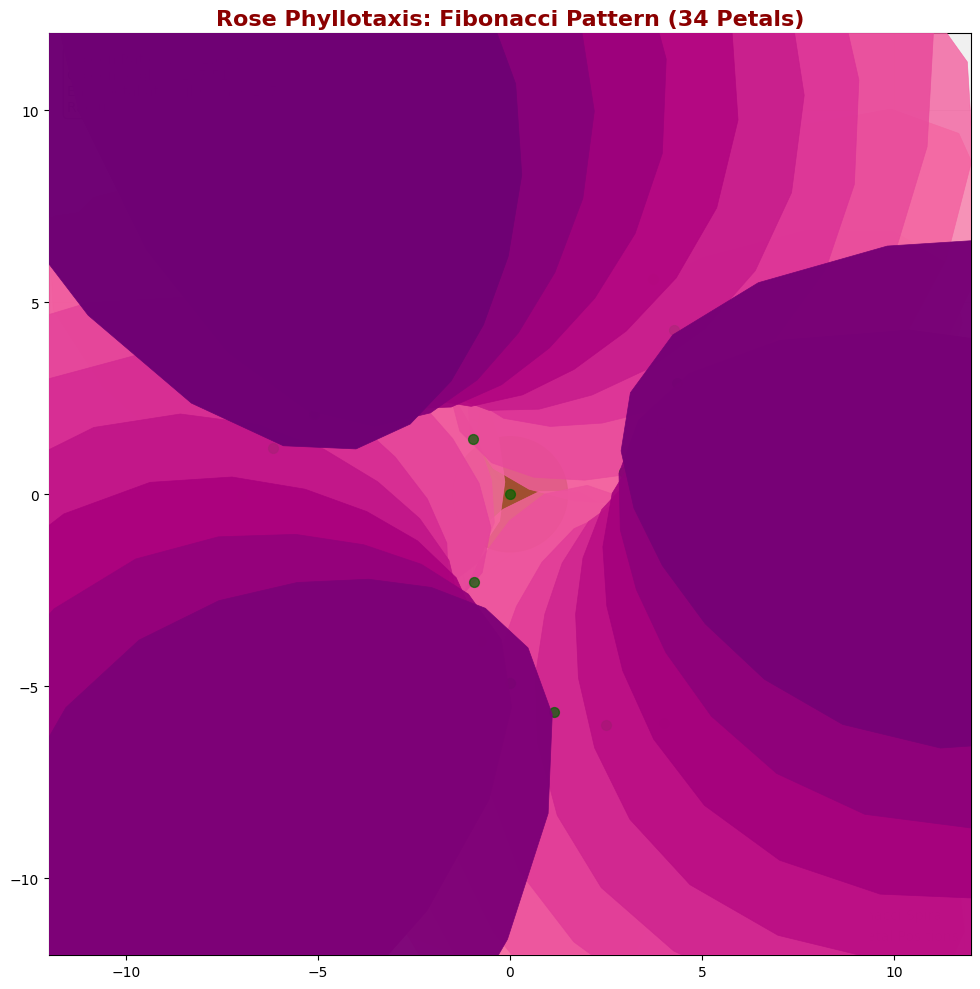


2. Showing different phyllotaxis patterns...


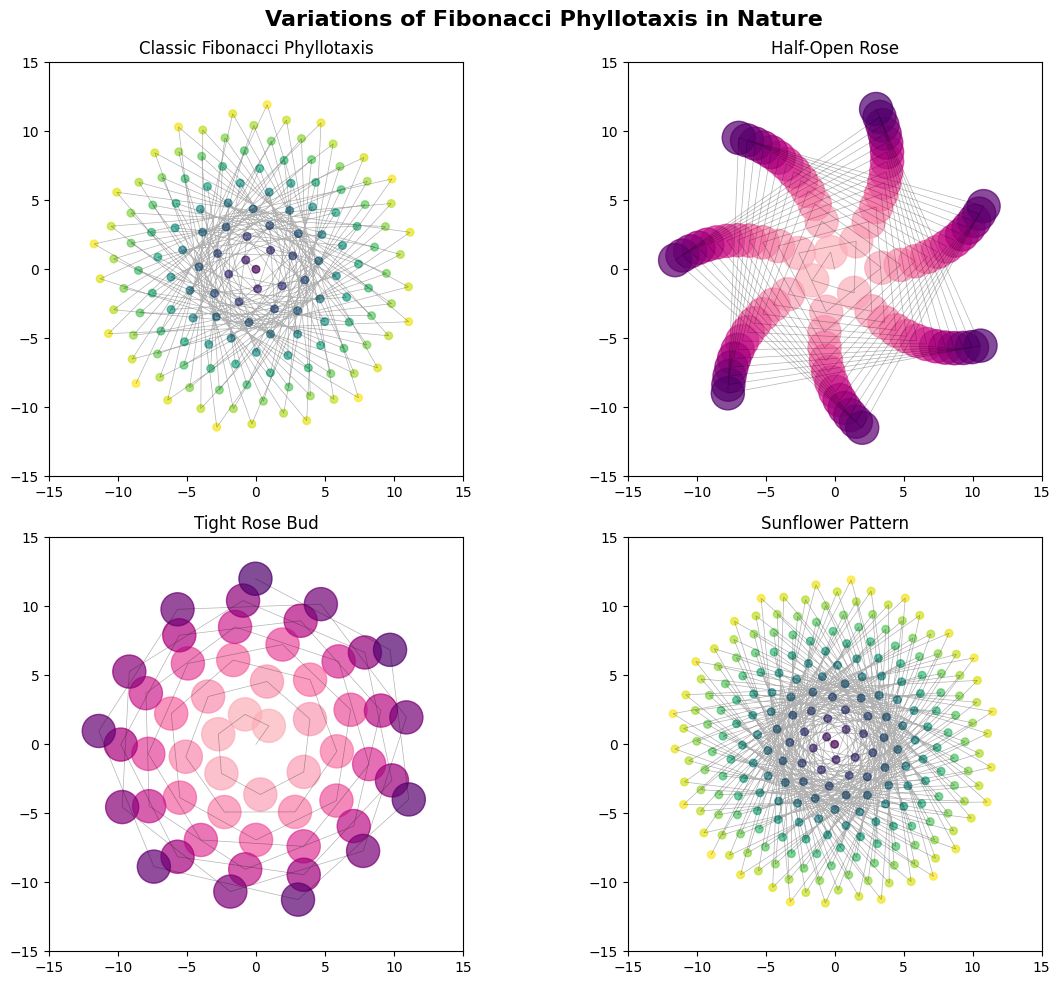


3. Creating animation of pattern emergence...


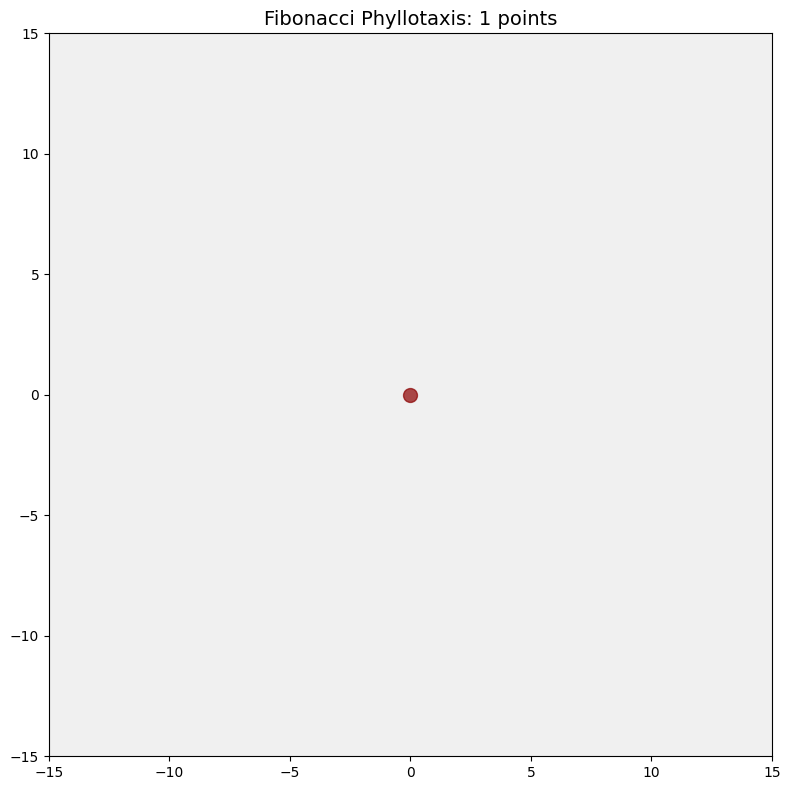


4. Mathematical coordinates for first 13 petals (like a rose):
Petal #  Angle (°)    X            Y           
------------------------------------------------
1              0.00      0.0000      0.0000
2            103.13     -0.0656      0.2811
3            206.26     -0.3661     -0.1806
4            309.39      0.3173     -0.3864
5             52.52      0.3513      0.4582
6            155.65     -0.5881      0.2661
7            258.78     -0.1375     -0.6936
8              1.92      0.7633      0.0255
9            105.05     -0.2120      0.7885
10           208.18     -0.7634     -0.4089
11           311.31      0.6026     -0.6857
12            54.44      0.5568      0.7789
13           157.57     -0.9243      0.3816

Pattern complete!
The Fibonacci phyllotaxis ensures optimal packing and exposure.
Each new petal is at angle ≈ 137.51° from the previous one.


In [ ]:
#@title Complete Phyllotaxis code - unchanged
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
from matplotlib.collections import PatchCollection
import matplotlib.animation as animation

def fibonacci_phyllotaxis(n_points, total_angle=np.pi*2, spiral_factor=1.0):
    """
    Generate Fibonacci phyllotaxis coordinates (the spiral pattern of rose petals).

    Parameters:
    - n_points: number of points/petals
    - total_angle: total angular spread (2π for full circle, π for half-open rose)
    - spiral_factor: controls how tight the spiral is (0 = flat disc, 1 = natural)

    Returns:
    - x, y coordinates of points
    - radii (distance from center)
    - angles (in radians)
    """
    phi = (1 + np.sqrt(5)) / 2  # Golden ratio
    golden_angle = 2 * np.pi / (phi ** 2)  # ~137.508 degrees in radians

    angles = np.zeros(n_points)
    radii = np.zeros(n_points)

    for i in range(n_points):
        # The classic Fibonacci phyllotaxis formula
        angle = i * golden_angle * total_angle / (2*np.pi)
        radius = spiral_factor * np.sqrt(i) if spiral_factor > 0 else np.sqrt(i)

        angles[i] = angle
        radii[i] = radius

    # Convert to Cartesian coordinates
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    return x, y, radii, angles

def create_petal_shape(x_center, y_center, angle, size, aspect_ratio=2.0):
    """
    Create polygon coordinates for a single petal.

    Parameters:
    - x_center, y_center: position of petal base
    - angle: orientation angle in radians
    - size: petal size
    - aspect_ratio: length/width ratio

    Returns:
    - Coordinates for a polygon representing the petal
    """
    # Base petal shape (an elongated ellipse/cardioid)
    t = np.linspace(0, 2*np.pi, 20)

    # Cardioid-like petal shape
    petal_r = size * (1 - 0.3 * np.sin(t))  # Creates a slight indentation

    # Create basic petal coordinates
    petal_x = petal_r * np.cos(t)
    petal_y = aspect_ratio * petal_r * np.sin(t) * (1 + 0.2 * np.cos(t))

    # Rotate and position
    cos_a, sin_a = np.cos(angle), np.sin(angle)

    rotated_x = petal_x * cos_a - petal_y * sin_a + x_center
    rotated_y = petal_x * sin_a + petal_y * cos_a + y_center

    return np.column_stack((rotated_x, rotated_y))

def draw_rose_phyllotaxis(n_petals=21, total_opening=np.pi*1.5, show_spiral=True):
    """
    Draw a rose using Fibonacci phyllotaxis.

    Parameters:
    - n_petals: number of petals to draw
    - total_opening: angular spread of the rose (2π = fully open top view)
    - show_spiral: whether to show the underlying Fibonacci spiral
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, alpha=0.3)

    # Generate phyllotaxis points
    x, y, radii, angles = fibonacci_phyllotaxis(
        n_petals,
        total_angle=total_opening,
        spiral_factor=1.2  # Makes it look more rose-like
    )

    # Normalize positions for better visualization
    max_r = np.max(radii[1:]) if len(radii) > 1 else 1
    x = x / max_r * 10
    y = y / max_r * 10
    radii = radii / max_r * 10

    # Draw center of rose
    center = Circle((0, 0), 1.5, color='#8B4513', alpha=0.8, zorder=10)
    ax.add_patch(center)

    # Draw petals (starting from outer to inner for proper layering)
    petal_colors = plt.cm.RdPu(np.linspace(0.3, 0.9, n_petals))

    # Create petals
    patches = []
    for i in range(n_petals-1, -1, -1):  # Draw from center outward
        if i == 0:
            continue  # Skip the very center point

        # Petal size increases with radius, but inner petals are relatively larger
        petal_size = 1.5 + 0.5 * radii[i]

        # Create petal shape
        petal_coords = create_petal_shape(
            x[i], y[i],
            angles[i] + np.pi/2,  # Rotate petals outward
            petal_size,
            aspect_ratio=1.8 if i < n_petals//2 else 1.5  # Outer petals more elongated
        )

        petal = Polygon(petal_coords, closed=True,
                       color=petal_colors[i],
                       alpha=0.7 + 0.3 * (i/n_petals),  # Inner petals more opaque
                       edgecolor='darkred',
                       linewidth=0.5,
                       zorder=i)
        ax.add_patch(petal)
        patches.append(petal)

    # Draw Fibonacci spiral (optional)
    if show_spiral:
        # Sort points by radius for smooth spiral
        sorted_indices = np.argsort(radii)
        sorted_x = x[sorted_indices]
        sorted_y = y[sorted_indices]

        ax.plot(sorted_x, sorted_y, 'k-', alpha=0.3, linewidth=1, label='Fibonacci Spiral')

        # Mark the points
        ax.scatter(x, y, color='darkgreen', s=50, alpha=0.7, zorder=20,
                  label=f'{n_petals} Petal Positions')

    # Add title and information
    ax.set_title(f'Rose Phyllotaxis: Fibonacci Pattern ({n_petals} Petals)',
                fontsize=16, fontweight='bold', color='darkred')

    # Add mathematical annotation
    phi = (1 + np.sqrt(5)) / 2
    golden_angle_deg = 360 / (phi ** 2)

    info_text = f'Golden Ratio (φ) = {phi:.4f}\nGolden Angle = {golden_angle_deg:.2f}°\n'
    info_text += f'Each petal at angle = n × {golden_angle_deg:.2f}°\n'
    info_text += f'Radius ∝ √n'

    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.legend(loc='lower right')
    plt.tight_layout()

    return fig, ax

def create_phyllotaxis_animation():
    """Create an animation showing how the Fibonacci pattern emerges."""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_facecolor('#f0f0f0')

    phi = (1 + np.sqrt(5)) / 2
    golden_angle = 2 * np.pi / (phi ** 2)

    # Prepare empty scatter plot
    scatter = ax.scatter([], [], s=100, color='darkred', alpha=0.7)
    ax.set_title('Fibonacci Phyllotaxis Emergence', fontsize=14)

    def animate(frame):
        n_points = frame + 1

        # Calculate positions for n_points
        x, y = [], []
        for i in range(n_points):
            angle = i * golden_angle
            radius = 2 * np.sqrt(i)
            x.append(radius * np.cos(angle))
            y.append(radius * np.sin(angle))

        scatter.set_offsets(np.column_stack((x, y)))
        ax.set_title(f'Fibonacci Phyllotaxis: {n_points} points', fontsize=14)

        return scatter,

    ani = animation.FuncAnimation(fig, animate, frames=100,
                                  interval=100, blit=True)

    plt.tight_layout()
    return ani

def sunflower_phyllotaxis_example():
    """Show the classic sunflower pattern (same mathematics as rose)."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    # Different variations of the pattern
    patterns = [
        ("Classic Fibonacci Phyllotaxis", 144, 2*np.pi, 1.0),
        ("Half-Open Rose", 89, np.pi*1.5, 1.2),
        ("Tight Rose Bud", 55, np.pi*0.8, 0.8),
        ("Sunflower Pattern", 233, 2*np.pi, 1.0),
    ]

    for idx, (title, n_points, total_angle, spiral_factor) in enumerate(patterns):
        ax = axes[idx]
        ax.set_aspect('equal')
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.set_title(title, fontsize=12)

        # Generate points
        x, y, radii, angles = fibonacci_phyllotaxis(n_points, total_angle, spiral_factor)

        # Normalize
        if len(radii) > 1:
            max_r = np.max(radii[1:])
            scale = 12 / max_r if max_r > 0 else 1
            x, y = x * scale, y * scale

        # Plot
        if "Rose" in title:
            # Draw as petals
            for i in range(min(n_points, 100)):
                if radii[i] > 0:
                    circle = Circle((x[i], y[i]), 1.2,
                                   color=plt.cm.RdPu(0.3 + 0.7*i/n_points),
                                   alpha=0.7)
                    ax.add_patch(circle)
        else:
            # Draw as dots
            ax.scatter(x, y, s=30, c=radii, cmap='viridis', alpha=0.7)

        # Add spiral
        sorted_idx = np.argsort(radii)
        ax.plot(x[sorted_idx], y[sorted_idx], 'k-', alpha=0.3, linewidth=0.5)

    plt.suptitle('Variations of Fibonacci Phyllotaxis in Nature',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig

# ===== MAIN EXECUTION =====
if __name__ == "__main__":
    print("Generating Fibonacci Phyllotaxis Visualizations...")
    print("This shows the mathematical pattern behind rose petal arrangement.")
    print("=" * 60)

    # 1. Draw a single rose with Fibonacci phyllotaxis
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=34, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Show sunflower/classic pattern
    print("\n2. Showing different phyllotaxis patterns...")
    fig2 = sunflower_phyllotaxis_example()
    plt.savefig('phyllotaxis_variations.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Create an animation (optional - comment out if you don't want animation)
    print("\n3. Creating animation of pattern emergence...")
    try:
        ani = create_phyllotaxis_animation()
        # To save animation:
        # ani.save('phyllotaxis_evolution.gif', writer='pillow', fps=10)
        plt.show()
    except:
        print("Animation requires additional setup. Proceeding to static plots...")

    # 4. Generate mathematical coordinates
    print("\n4. Mathematical coordinates for first 13 petals (like a rose):")
    x, y, radii, angles = fibonacci_phyllotaxis(13, np.pi*1.5, 1.2)

    # Normalize for display
    max_r = np.max(radii[1:]) if len(radii) > 1 else 1
    x, y = x/max_r, y/max_r

    print(f"{'Petal #':<8} {'Angle (°)':<12} {'X':<12} {'Y':<12}")
    print("-" * 48)
    for i in range(min(13, len(angles))):
        print(f"{i+1:<8} {np.degrees(angles[i]) % 360:>10.2f} {x[i]:>11.4f} {y[i]:>11.4f}")

    print("\n" + "=" * 60)
    print("Pattern complete!")
    print("The Fibonacci phyllotaxis ensures optimal packing and exposure.")
    print(f"Each new petal is at angle ≈ {137.508:.2f}° from the previous one.")

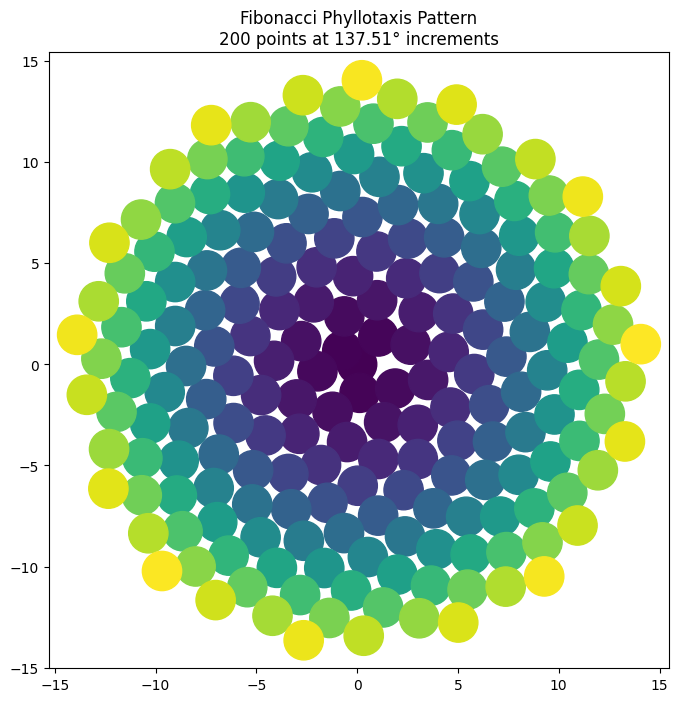

In [ ]:
#@title Simple Python Demonstration of Fibonacci Phyllotaxis - I think it is not used in the paper.
import matplotlib.pyplot as plt
import numpy as np

# Golden ratio and angle
phi = (1 + np.sqrt(5)) / 2
golden_angle = 2 * np.pi / (phi ** 2)  # in radians

# Generate points
n_points = 200
angles = [i * golden_angle for i in range(n_points)]
radii = [np.sqrt(i) for i in range(n_points)]

# Convert to Cartesian coordinates
x = [r * np.cos(a) for r, a in zip(radii, angles)]
y = [r * np.sin(a) for r, a in zip(radii, angles)]

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=40, c=range(n_points), cmap='viridis')
plt.title(f"Fibonacci Phyllotaxis Pattern\n{n_points} points at {np.degrees(golden_angle):.2f}° increments")
plt.axis('equal')
plt.show()

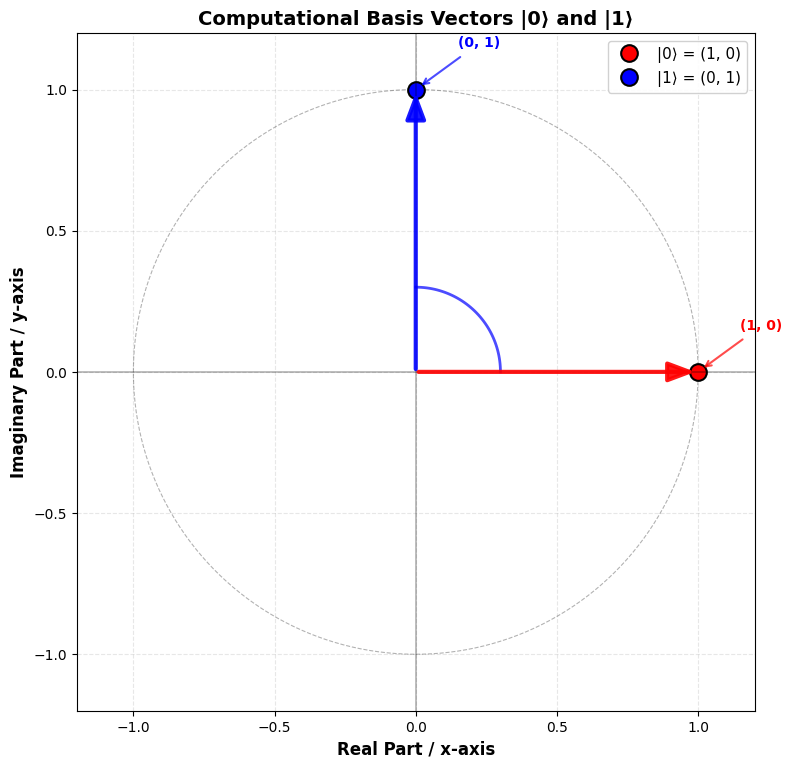

COMPUTATIONAL BASIS VECTORS:
|0⟩ = (1, 0)
|1⟩ = (0, 1)

VECTOR PROPERTIES:
• Magnitude of |0⟩: 1.0
• Magnitude of |1⟩: 1.0
• Dot product (orthogonality): 0
• Angle between vectors: 90° (π/2 radians)

QUANTUM COMPUTING CONTEXT:
• These form an orthonormal basis for a qubit state space
• Any qubit state |ψ⟩ = α|0⟩ + β|1⟩ where |α|² + |β|² = 1
• |0⟩ and |1⟩ are eigenstates of the Pauli-Z operator


In [ ]:
#@title Show the computational basis

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Create the unitary vectors
vectors = [
    (1, 0, 'red', '|0⟩ = (1, 0)'),
    (0, 1, 'blue', '|1⟩ = (0, 1)')
]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the unit circle (for reference)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)

# Plot the vectors as arrows
for x, y, color, label in vectors:
    # Plot the endpoint
    ax.plot(x, y, 'o', markersize=12, color=color, label=label,
            markeredgecolor='black', markeredgewidth=1.5)

    # Draw a prominent vector arrow from origin to the vector endpoint
    arrow = FancyArrowPatch((0, 0), (x, y),
                            arrowstyle='-|>,head_width=0.3,head_length=0.8',
                            color=color,
                            linewidth=3,
                            alpha=0.9,
                            zorder=3,
                            mutation_scale=20)
    ax.add_patch(arrow)

    # Add angle indicators
    angle = np.arctan2(y, x)

    # Draw angle arc for y-axis vector (has non-zero angle)
    if abs(angle) > 0.01:  # Only draw arc for non-zero angles
        arc_theta = np.linspace(0, angle, 50)
        arc_radius = 0.3
        ax.plot(arc_radius * np.cos(arc_theta), arc_radius * np.sin(arc_theta),
                color=color, alpha=0.7, linewidth=2)

# Set plot properties
ax.set_aspect('equal')
ax.axhline(y=0, color='k', alpha=0.3, linewidth=1.2)
ax.axvline(x=0, color='k', alpha=0.3, linewidth=1.2)
ax.grid(True, alpha=0.3, linestyle='--')

# Set limits and labels
lim = 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Real Part / x-axis', fontsize=12, fontweight='bold')
ax.set_ylabel('Imaginary Part / y-axis', fontsize=12, fontweight='bold')
ax.set_title('Computational Basis Vectors |0⟩ and |1⟩', fontsize=14, fontweight='bold')

# Add legend
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Add annotations for coordinates with arrows
for x, y, color, label in vectors:
    offset_x = 0.15 if x >= 0 else -0.25
    offset_y = 0.15 if y >= 0 else -0.2

    ax.annotate(f'({x}, {y})',
                xy=(x, y),
                xytext=(x + offset_x, y + offset_y),
                fontsize=10,
                fontweight='bold',
                color=color,
                arrowprops=dict(arrowstyle='->',
                              color=color,
                              alpha=0.7,
                              linewidth=1.5,
                              shrinkA=5, shrinkB=5))

# Add vector magnitude indicators
# ax.text(0.5, -0.1, '‖v‖ = 1', fontsize=9, ha='center', color='darkred',
#        bbox=dict(boxstyle='round,pad=0.2', facecolor='w', alpha=0.7))
# ax.text(-0.1, 0.5, '‖v‖ = 1', fontsize=9, ha='center', color='darkblue',
#        bbox=dict(boxstyle='round,pad=0.2', facecolor='w', alpha=0.7), rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

# Print vector information
print("COMPUTATIONAL BASIS VECTORS:")
print("="*40)
print("|0⟩ = (1, 0)")
print("|1⟩ = (0, 1)")
print("\nVECTOR PROPERTIES:")
print("• Magnitude of |0⟩:", np.linalg.norm([1, 0]))
print("• Magnitude of |1⟩:", np.linalg.norm([0, 1]))
print("• Dot product (orthogonality):", np.dot([1, 0], [0, 1]))
print("• Angle between vectors: 90° (π/2 radians)")
print("\nQUANTUM COMPUTING CONTEXT:")
print("• These form an orthonormal basis for a qubit state space")
print("• Any qubit state |ψ⟩ = α|0⟩ + β|1⟩ where |α|² + |β|² = 1")
print("• |0⟩ and |1⟩ are eigenstates of the Pauli-Z operator")

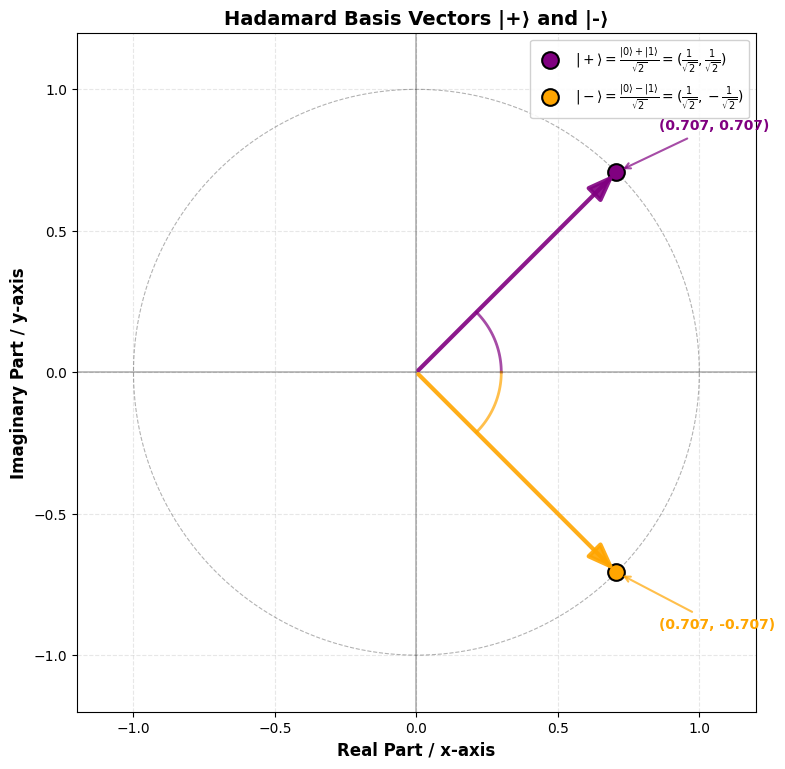

HADAMARD BASIS VECTORS:
|+⟩ = (1/√2, 1/√2) ≈ (0.707107, 0.707107)
|-⟩ = (1/√2, -1/√2) ≈ (0.707107, -0.707107)

VECTOR PROPERTIES:
• Magnitude of |+⟩: 1.000000
• Magnitude of |-⟩: 1.000000
• Dot product (orthogonality): 0.000000
• Angle between vectors: 90° (π/2 radians)

QUANTUM COMPUTING CONTEXT:
• These form an orthonormal basis for a qubit state space
• |+⟩ and |-⟩ are eigenstates of the Pauli-X operator
• They are obtained by applying the Hadamard gate to |0⟩ and |1⟩:
  H|0⟩ = |+⟩
  H|1⟩ = |-⟩
• Any qubit state |ψ⟩ = α|+⟩ + β|-⟩ where |α|² + |β|² = 1


In [ ]:
#@title Show the Hadamard basis

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Create the Hadamard basis vectors
# |+⟩ = (|0⟩ + |1⟩)/√2 = (1/√2, 1/√2)
# |-⟩ = (|0⟩ - |1⟩)/√2 = (1/√2, -1/√2)
sqrt2_inv = 1/np.sqrt(2)

vectors = [
    (sqrt2_inv, sqrt2_inv, 'purple', r'$|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = (\frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}})$'),
    (sqrt2_inv, -sqrt2_inv, 'orange', r'$|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = (\frac{1}{\sqrt{2}}, -\frac{1}{\sqrt{2}})$')
]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the unit circle (for reference)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)

# Plot the vectors as arrows
for x, y, color, label in vectors:
    # Plot the endpoint
    ax.plot(x, y, 'o', markersize=12, color=color, label=label,
            markeredgecolor='black', markeredgewidth=1.5)

    # Draw a prominent vector arrow from origin to the vector endpoint
    arrow = FancyArrowPatch((0, 0), (x, y),
                            arrowstyle='-|>,head_width=0.3,head_length=0.8',
                            color=color,
                            linewidth=3,
                            alpha=0.9,
                            zorder=3,
                            mutation_scale=20)
    ax.add_patch(arrow)

    # Add angle indicators
    angle = np.arctan2(y, x)

    # Draw angle arc for vectors (has non-zero angle)
    if abs(angle) > 0.01:  # Only draw arc for non-zero angles
        arc_theta = np.linspace(0, angle, 50)
        arc_radius = 0.3
        ax.plot(arc_radius * np.cos(arc_theta), arc_radius * np.sin(arc_theta),
                color=color, alpha=0.7, linewidth=2)

# Set plot properties
ax.set_aspect('equal')
ax.axhline(y=0, color='k', alpha=0.3, linewidth=1.2)
ax.axvline(x=0, color='k', alpha=0.3, linewidth=1.2)
ax.grid(True, alpha=0.3, linestyle='--')

# Set limits and labels
lim = 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Real Part / x-axis', fontsize=12, fontweight='bold')
ax.set_ylabel('Imaginary Part / y-axis', fontsize=12, fontweight='bold')
ax.set_title('Hadamard Basis Vectors |+⟩ and |-⟩', fontsize=14, fontweight='bold')

# Add legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Add annotations for coordinates with arrows
for x, y, color, label in vectors:
    offset_x = 0.15 if x >= 0 else -0.25
    offset_y = 0.15 if y >= 0 else -0.2

    ax.annotate(f'({x:.3f}, {y:.3f})',
                xy=(x, y),
                xytext=(x + offset_x, y + offset_y),
                fontsize=10,
                fontweight='bold',
                color=color,
                arrowprops=dict(arrowstyle='->',
                              color=color,
                              alpha=0.7,
                              linewidth=1.5,
                              shrinkA=5, shrinkB=5))

# Show the plot
plt.tight_layout()
plt.show()

# Print vector information
print("HADAMARD BASIS VECTORS:")
print("="*40)
print(f"|+⟩ = (1/√2, 1/√2) ≈ ({sqrt2_inv:.6f}, {sqrt2_inv:.6f})")
print(f"|-⟩ = (1/√2, -1/√2) ≈ ({sqrt2_inv:.6f}, {-sqrt2_inv:.6f})")
print("\nVECTOR PROPERTIES:")
print(f"• Magnitude of |+⟩: {np.linalg.norm([sqrt2_inv, sqrt2_inv]):.6f}")
print(f"• Magnitude of |-⟩: {np.linalg.norm([sqrt2_inv, -sqrt2_inv]):.6f}")
print(f"• Dot product (orthogonality): {np.dot([sqrt2_inv, sqrt2_inv], [sqrt2_inv, -sqrt2_inv]):.6f}")
print(f"• Angle between vectors: 90° (π/2 radians)")
print("\nQUANTUM COMPUTING CONTEXT:")
print("• These form an orthonormal basis for a qubit state space")
print("• |+⟩ and |-⟩ are eigenstates of the Pauli-X operator")
print("• They are obtained by applying the Hadamard gate to |0⟩ and |1⟩:")
print("  H|0⟩ = |+⟩")
print("  H|1⟩ = |-⟩")
print("• Any qubit state |ψ⟩ = α|+⟩ + β|-⟩ where |α|² + |β|² = 1")

In [ ]:
#@title Show the complex tertiary roots of unity
import numpy as np
import matplotlib.pyplot as plt

# Calculate the cube roots of unity
n = 3
roots = np.exp(1j * 2 * np.pi * np.arange(n) / n)

# Create the plot
fig, ax = plt.subplots(figsize=(9, 8))

# Plot the unit circle
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, linewidth=0.8)

# Plot vectors using quiver (arrow plots)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['ω₀ = 1', 'ω₁ = e^(2πi/3)', 'ω₂ = e^(4πi/3)']

# Extract real and imaginary parts for quiver
x_origins = [0, 0, 0]
y_origins = [0, 0, 0]
x_ends = [root.real for root in roots]
y_ends = [root.imag for root in roots]

# Plot vectors
for i in range(n):
    ax.quiver(x_origins[i], y_origins[i],
              x_ends[i], y_ends[i],
              angles='xy', scale_units='xy', scale=1,
              color=colors[i], alpha=0.8, width=0.015,
              label=labels[i])

# Plot the root points
for i, root in enumerate(roots):
    ax.plot(root.real, root.imag, 'o', markersize=12,
            color=colors[i], markeredgecolor='black', markeredgewidth=1)

# Add angle information and arcs
for i, root in enumerate(roots):
    angle = np.angle(root)
    if angle < 0:
        angle += 2*np.pi

    # Draw angle arc
    arc_theta = np.linspace(0, angle, 100)
    arc_radius = 0.25
    arc_x = arc_radius * np.cos(arc_theta)
    arc_y = arc_radius * np.sin(arc_theta)
    ax.plot(arc_x, arc_y, color=colors[i], alpha=0.7, linewidth=2)

    # Add angle label
    label_radius = 0.35
    label_x = label_radius * np.cos(angle/2)
    label_y = label_radius * np.sin(angle/2)

    angle_text = f'{angle/np.pi:.2f}π' if angle > 0 else '0'
    ax.text(label_x, label_y, angle_text,
            fontsize=10, color=colors[i], fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Add coordinate annotations with arrows
for i, root in enumerate(roots):
    offset_mult = 1.1
    annotation_x = root.real * offset_mult
    annotation_y = root.imag * offset_mult

    ax.annotate(f'({root.real:.2f}, {root.imag:.2f}i)',
                xy=(root.real, root.imag),
                xytext=(annotation_x, annotation_y),
                fontsize=10, fontweight='bold',
                color=colors[i],
                arrowprops=dict(arrowstyle='->',
                              color=colors[i],
                              alpha=0.7,
                              linewidth=1.5,
                              connectionstyle="arc3,rad=0.1"))

# Set plot properties
ax.set_aspect('equal')
ax.axhline(y=0, color='k', alpha=0.3, linewidth=0.8)
ax.axvline(x=0, color='k', alpha=0.3, linewidth=0.8)
ax.grid(True, alpha=0.3, linestyle='--')

# Set limits and labels
lim = 1.4
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Real Axis (Re)', fontsize=12, fontweight='bold')
ax.set_ylabel('Imaginary Axis (Im)', fontsize=12, fontweight='bold')
ax.set_title('Cube Roots of Unity as Complex Vectors',
             fontsize=16, fontweight='bold', pad=20)

# Add legend
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

'''
# Add text box with properties
properties_text = (
    "Properties:\n"
    "1. All vectors have magnitude 1\n"
    "2. Angles: 0°, 120°, 240°\n"
    "3. Vector sum = 0\n"
    "4. Form equilateral triangle"
)
ax.text(-1.3, -1.2, properties_text,
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
'''
plt.tight_layout()
plt.show()

# Print detailed information
print("="*60)
print("CUBE ROOTS OF UNITY AS VECTORS")
print("="*60)
print(f"ω₀ = 1: Vector (1, 0) with angle 0°")
print(f"ω₁ = e^(2πi/3): Vector (-0.5, {np.sqrt(3)/2:.4f}) with angle 120°")
print(f"ω₂ = e^(4πi/3): Vector (-0.5, -{np.sqrt(3)/2:.4f}) with angle 240°")
print("\nVector operations:")
print(f"ω₁ · ω₂ = {np.dot([roots[1].real, roots[1].imag], [roots[2].real, roots[2].imag]):.4f}")
print(f"|ω₁| = {np.abs(roots[1]):.4f}, |ω₂| = {np.abs(roots[2]):.4f}")
print(f"Angle between ω₁ and ω₂: {np.angle(roots[1]/roots[2]):.4f} radians")

In [ ]:
#@title Alternative option to Show the complex tertiary roots of unity

import numpy as np
import matplotlib.pyplot as plt

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Cube roots of unity
n = 3
roots = np.exp(1j * 2 * np.pi * np.arange(n) / n)

# Plot 1: Roots on complex plane
ax1.set_aspect('equal')
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.3)
ax1.add_artist(circle)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
labels = ['1', 'e^(2πi/3)', 'e^(4πi/3)']

for i, (root, color, label) in enumerate(zip(roots, colors, labels)):
    ax1.plot([0, root.real], [0, root.imag], color=color, alpha=0.5, linewidth=2)
    ax1.plot(root.real, root.imag, 'o', markersize=12, color=color,
             label=f'ω^{i} = {label}')

    # Add angle text
    angle = np.angle(root)
    if angle < 0:
        angle += 2*np.pi
    angle_text = f'{angle/np.pi:.2f}π' if angle > 0 else '0'
    ax1.text(0.6*np.cos(angle/2), 0.6*np.sin(angle/2),
             angle_text, fontsize=10, color=color)

ax1.axhline(y=0, color='k', alpha=0.2)
ax1.axvline(x=0, color='k', alpha=0.2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)
ax1.set_xlabel('Re(z)', fontsize=12)
ax1.set_ylabel('Im(z)', fontsize=12)
ax1.set_title('Cube Roots of Unity on Complex Plane', fontsize=14)
ax1.legend(loc='upper right')

# Plot 2: Polar plot showing symmetry
ax2 = fig.add_subplot(122, projection='polar')
theta = np.linspace(0, 2*np.pi, 200)
ax2.plot(theta, np.ones_like(theta), 'k--', alpha=0.3)

for i, (root, color) in enumerate(zip(roots, colors)):
    angle = np.angle(root)
    if angle < 0:
        angle += 2*np.pi
    ax2.plot([0, angle], [0, 1], color=color, linewidth=2)
    ax2.plot(angle, 1, 'o', markersize=12, color=color,
             label=f'ω^{i}: θ={angle/np.pi:.2f}π')

ax2.set_rmax(1.1)
ax2.set_title('Roots in Polar Coordinates', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print mathematical properties
print("="*50)
print("MATHEMATICAL PROPERTIES:")
print("="*50)
print("1. Roots satisfy: ω³ = 1")
print("2. Sum of roots: ω₀ + ω₁ + ω₂ = 0")
print("3. Multiplication: ω₁ × ω₂ = 1")
print("4. Conjugates: ω₁ and ω₂ are complex conjugates")
print("\nExact values:")
print(f"ω₀ = 1")
print(f"ω₁ = -1/2 + i√3/2 ≈ {roots[1].real:.4f} + {roots[1].imag:.4f}i")
print(f"ω₂ = -1/2 - i√3/2 ≈ {roots[2].real:.4f} + {roots[2].imag:.4f}i")

In [ ]:
#@title Show Rose Petals
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
from matplotlib.collections import PatchCollection
import matplotlib.animation as animation

def fibonacci_phyllotaxis(n_points, total_angle=np.pi*2, spiral_factor=1.0):
    """
    Generate Fibonacci phyllotaxis coordinates (the spiral pattern of rose petals).

    Parameters:
    - n_points: number of points/petals
    - total_angle: total angular spread (2π for full circle, π for half-open rose)
    - spiral_factor: controls how tight the spiral is (0 = flat disc, 1 = natural)

    Returns:
    - x, y coordinates of points
    - radii (distance from center)
    - angles (in radians)
    """
    phi = (1 + np.sqrt(5)) / 2  # Golden ratio
    golden_angle = 2 * np.pi / (phi ** 2)  # ~137.508 degrees in radians

    angles = np.zeros(n_points)
    radii = np.zeros(n_points)

    for i in range(n_points):
        # The classic Fibonacci phyllotaxis formula
        angle = i * golden_angle * total_angle / (2*np.pi)
        radius = spiral_factor * np.sqrt(i) if spiral_factor > 0 else np.sqrt(i)

        angles[i] = angle
        radii[i] = radius

    # Convert to Cartesian coordinates
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    return x, y, radii, angles

def create_petal_shape(x_center, y_center, angle, size, aspect_ratio=2.0):
    """
    Create polygon coordinates for a single petal.

    Parameters:
    - x_center, y_center: position of petal base
    - angle: orientation angle in radians
    - size: petal size
    - aspect_ratio: length/width ratio

    Returns:
    - Coordinates for a polygon representing the petal
    """
    # Base petal shape (an elongated ellipse/cardioid)
    t = np.linspace(0, 2*np.pi, 20)

    # Cardioid-like petal shape
    petal_r = size * (1 - 0.3 * np.sin(t))  # Creates a slight indentation

    # Create basic petal coordinates
    petal_x = petal_r * np.cos(t)
    petal_y = aspect_ratio * petal_r * np.sin(t) * (1 + 0.2 * np.cos(t))

    # Rotate and position
    cos_a, sin_a = np.cos(angle), np.sin(angle)

    rotated_x = petal_x * cos_a - petal_y * sin_a + x_center
    rotated_y = petal_x * sin_a + petal_y * cos_a + y_center

    return np.column_stack((rotated_x, rotated_y))

def draw_rose_phyllotaxis(n_petals=21, total_opening=np.pi*1.5, show_spiral=False):
# def draw_rose_phyllotaxis(n_petals=3, total_opening=np.pi*1.5, show_spiral=False):
    """
    Draw a rose using Fibonacci phyllotaxis.

    Parameters:
    - n_petals: number of petals to draw
    - total_opening: angular spread of the rose (2π = fully open top view)
    - show_spiral: whether to show the underlying Fibonacci spiral
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, alpha=0.3)

    # Generate phyllotaxis points
    x, y, radii, angles = fibonacci_phyllotaxis(
        n_petals,
        total_angle=total_opening,
        spiral_factor=1.2  # Makes it look more rose-like
    )

    # Normalize positions for better visualization
    max_r = np.max(radii[1:]) if len(radii) > 1 else 1
    x = x / max_r * 10
    y = y / max_r * 10
    radii = radii / max_r * 10

    # Draw center of rose
    center = Circle((0, 0), 1.5, color='#8B4513', alpha=0.8, zorder=10)
    ax.add_patch(center)

    # Draw petals (starting from outer to inner for proper layering)
    petal_colors = plt.cm.RdPu(np.linspace(0.3, 0.9, n_petals))

    # Create petals
    patches = []
    for i in range(n_petals-1, -1, -1):  # Draw from center outward
        if i == 0:
            continue  # Skip the very center point

        # Petal size increases with radius, but inner petals are relatively larger
        petal_size = 1.5 + 0.5 * radii[i]

        # Create petal shape
        petal_coords = create_petal_shape(
            x[i], y[i],
            angles[i] + np.pi/2,  # Rotate petals outward
            petal_size,
            aspect_ratio=1.8 if i < n_petals//2 else 1.5  # Outer petals more elongated
        )

        petal = Polygon(petal_coords, closed=True,
                       color=petal_colors[i],
                       alpha=0.7 + 0.3 * (i/n_petals),  # Inner petals more opaque
                       edgecolor='darkred',
                       linewidth=0.5,
                       zorder=i)
        ax.add_patch(petal)
        patches.append(petal)

    # Draw Fibonacci spiral (optional)
    if show_spiral:
        # Sort points by radius for smooth spiral
        sorted_indices = np.argsort(radii)
        sorted_x = x[sorted_indices]
        sorted_y = y[sorted_indices]

        ax.plot(sorted_x, sorted_y, 'k-', alpha=0.3, linewidth=1, label='Fibonacci Spiral')

        # Mark the points
        ax.scatter(x, y, color='darkgreen', s=50, alpha=0.7, zorder=20,
                  label=f'{n_petals} Petal Positions')

    # Add title and information
    # ax.set_title(f'Rose Phyllotaxis: Fibonacci Pattern ({n_petals} Petals)',
    #            fontsize=16, fontweight='bold', color='darkred')

    # Add mathematical annotation
    phi = (1 + np.sqrt(5)) / 2
    golden_angle_deg = 360 / (phi ** 2)

    info_text = f'Golden Ratio (φ) = {phi:.4f}\nGolden Angle = {golden_angle_deg:.2f}°\n'
    info_text += f'Each petal at angle = n × {golden_angle_deg:.2f}°\n'
    info_text += f'Radius ∝ √n'

    '''
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.legend(loc='lower right')
    '''
    plt.tight_layout()

    return fig, ax


# ===== MAIN EXECUTION =====
if __name__ == "__main__":
    print("Generating Fibonacci Phyllotaxis Visualizations...")
    print("This shows the mathematical pattern behind rose petal arrangement.")
    print("=" * 60)

    # 34. Draw a single rose with Fibonacci phyllotaxis, n_petals=34
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=34, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()


    # 2. Draw a single rose with Fibonacci phyllotaxis, n_petals=2
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=2, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()


    # 3. Draw a single rose with Fibonacci phyllotaxis, n_petals=3
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=3, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. Draw a single rose with Fibonacci phyllotaxis, n_petals=4
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=4, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 5. Draw a single rose with Fibonacci phyllotaxis, n_petals=5
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=5, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 6. Draw a single rose with Fibonacci phyllotaxis, n_petals=6
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=6, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()





In [ ]:
#@title Show Rose Petal Centers
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
from matplotlib.collections import PatchCollection
import matplotlib.animation as animation

def fibonacci_phyllotaxis(n_points, total_angle=np.pi*2, spiral_factor=1.0):
    """
    Generate Fibonacci phyllotaxis coordinates (the spiral pattern of rose petals).

    Parameters:
    - n_points: number of points/petals
    - total_angle: total angular spread (2π for full circle, π for half-open rose)
    - spiral_factor: controls how tight the spiral is (0 = flat disc, 1 = natural)

    Returns:
    - x, y coordinates of points
    - radii (distance from center)
    - angles (in radians)
    """
    phi = (1 + np.sqrt(5)) / 2  # Golden ratio
    golden_angle = 2 * np.pi / (phi ** 2)  # ~137.508 degrees in radians

    angles = np.zeros(n_points)
    radii = np.zeros(n_points)

    for i in range(n_points):
        # The classic Fibonacci phyllotaxis formula
        angle = i * golden_angle * total_angle / (2*np.pi)
        radius = spiral_factor * np.sqrt(i) if spiral_factor > 0 else np.sqrt(i)

        angles[i] = angle
        radii[i] = radius

    # Convert to Cartesian coordinates
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)

    return x, y, radii, angles

def create_petal_shape(x_center, y_center, angle, size, aspect_ratio=2.0):
    """
    Create polygon coordinates for a single petal.

    Parameters:
    - x_center, y_center: position of petal base
    - angle: orientation angle in radians
    - size: petal size
    - aspect_ratio: length/width ratio

    Returns:
    - Coordinates for a polygon representing the petal
    """
    # Base petal shape (an elongated ellipse/cardioid)
    t = np.linspace(0, 2*np.pi, 20) #creates linearly spaced numbers between 0 and 2*pi.

    # Cardioid-like petal shape
    petal_r = size * (1 - 0.3 * np.sin(t))  # Creates a slight indentation

    # Create basic petal coordinates
    petal_x = petal_r * np.cos(t)
    petal_y = aspect_ratio * petal_r * np.sin(t) * (1 + 0.2 * np.cos(t))

    # Rotate and position
    cos_a, sin_a = np.cos(angle), np.sin(angle)

    rotated_x = petal_x * cos_a - petal_y * sin_a + x_center
    rotated_y = petal_x * sin_a + petal_y * cos_a + y_center

    # print ("**********Output of create_petal_shape")
    # print (rotated_x)

    return np.column_stack((rotated_x, rotated_y))

def draw_rose_phyllotaxis(n_petals=21, total_opening=np.pi*1.5, show_spiral=False):
# def draw_rose_phyllotaxis(n_petals=3, total_opening=np.pi*1.5, show_spiral=False):
    """
    Draw a rose using Fibonacci phyllotaxis.

    Parameters:
    - n_petals: number of petals to draw
    - total_opening: angular spread of the rose (2π = fully open top view)
    - show_spiral: whether to show the underlying Fibonacci spiral
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')
    ax.set_xlim(-12, 12)
    ax.set_ylim(-12, 12)
    ax.set_facecolor('#f0f0f0')
    ax.grid(True, alpha=0.3)

    # Generate phyllotaxis points
    x, y, radii, angles = fibonacci_phyllotaxis(
        n_petals,
        total_angle=total_opening,
        spiral_factor=1.2  # Makes it look more rose-like
    )

    # Normalize positions for better visualization
    max_r = np.max(radii[1:]) if len(radii) > 1 else 1
    x = x / max_r * 10
    y = y / max_r * 10
    radii = radii / max_r * 10

    # Draw center of rose
    center = Circle((0, 0), 1.5, color='#8B4513', alpha=0.8, zorder=10)
    ax.add_patch(center)

    # Draw petals (starting from outer to inner for proper layering)
    petal_colors = plt.cm.RdPu(np.linspace(0.3, 0.9, n_petals))

    # Create petals
    patches = []
    for i in range(n_petals-1, -1, -1):  # Draw from center outward
        if i == 0:
            continue  # Skip the very center point

        # Petal size increases with radius, but inner petals are relatively larger
        petal_size = 1.5 + 0.5 * radii[i]

        # Create petal shape
        petal_coords = create_petal_shape(
            x[i], y[i],
            angles[i] + np.pi/2,  # Rotate petals outward
            petal_size,
            aspect_ratio=1.8 if i < n_petals//2 else 1.5  # Outer petals more elongated
        )

        petal = Polygon(petal_coords, closed=True,
                       color=petal_colors[i],
                       alpha=0.7 + 0.3 * (i/n_petals),  # Inner petals more opaque
                       edgecolor='darkred',
                       linewidth=0.5,
                       zorder=i)
        #ax.add_patch(petal)
        floret = Circle((x[i], y[i]),  # center coordinates
              radius=1.0,  # disk radius
              color='skyblue',
              alpha=0.8,
              edgecolor='darkblue',
              linewidth=1.0,
              zorder=0)
        ax.add_patch(floret)
        patches.append(petal)

    # Draw Fibonacci spiral (optional)
    if show_spiral:
        # Sort points by radius for smooth spiral
        sorted_indices = np.argsort(radii)
        sorted_x = x[sorted_indices]
        sorted_y = y[sorted_indices]

        ax.plot(sorted_x, sorted_y, 'k-', alpha=0.3, linewidth=1, label='Fibonacci Spiral')

        # Mark the points
        ax.scatter(x, y, color='darkgreen', s=50, alpha=0.7, zorder=20,
                  label=f'{n_petals} Petal Positions')

    # Add title and information
    ax.set_title(f'Rose Phyllotaxis: Fibonacci Pattern ({n_petals} Petals)',
                fontsize=16, fontweight='bold', color='darkred')

    # Add mathematical annotation
    phi = (1 + np.sqrt(5)) / 2
    golden_angle_deg = 360 / (phi ** 2)

    info_text = f'Golden Ratio (φ) = {phi:.4f}\nGolden Angle = {golden_angle_deg:.2f}°\n'
    info_text += f'Each petal at angle = n × {golden_angle_deg:.2f}°\n'
    info_text += f'Radius ∝ √n'

    '''
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.legend(loc='lower right')
    '''
    plt.tight_layout()

    return fig, ax


# ===== MAIN EXECUTION =====
if __name__ == "__main__":
    print("Generating Fibonacci Phyllotaxis Visualizations...")
    print("This shows the mathematical pattern behind rose petal arrangement.")
    print("=" * 60)


    # 30. Draw a single rose with Fibonacci phyllotaxis, n_petals=34
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    # fig1, ax1 = draw_rose_phyllotaxis(n_petals=34, total_opening=np.pi*1.8)
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=34, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()


    # 2. Draw a single rose with Fibonacci phyllotaxis, n_petals=2
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    # fig1, ax1 = draw_rose_phyllotaxis(n_petals=2, total_opening=np.pi*1.8)
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=2, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()


    # 3. Draw a single rose with Fibonacci phyllotaxis, n_petals=3
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    # fig1, ax1 = draw_rose_phyllotaxis(n_petals=3, total_opening=np.pi*1.8)
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=3, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. Draw a single rose with Fibonacci phyllotaxis, n_petals=4
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    # fig1, ax1 = draw_rose_phyllotaxis(n_petals=4, total_opening=np.pi*1.8)
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=4, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 5. Draw a single rose with Fibonacci phyllotaxis, n_petals=5
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    # fig1, ax1 = draw_rose_phyllotaxis(n_petals=5, total_opening=np.pi*1.8)
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=5, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 6. Draw a single rose with Fibonacci phyllotaxis, n_petals=6
    print("\n1. Drawing a rose using Fibonacci phyllotaxis...")
    # fig1, ax1 = draw_rose_phyllotaxis(n_petals=6, total_opening=np.pi*1.8)
    fig1, ax1 = draw_rose_phyllotaxis(n_petals=6, total_opening=np.pi*1.8)
    plt.savefig('rose_phyllotaxis.png', dpi=150, bbox_inches='tight')
    plt.show()





ID Quantique QKD Management System - 4-Node Network Visualization
This diagram shows a 4-node quantum network with layered architecture:
  • Nodes A, B, C, D each contain three layers
  • Quantum Layer (bottom): Point-to-point QKD key generation [citation:3]
  • KMS Layer (middle): Key routing and network extension [citation:1]
  • Application Layer (top): Key consumption by encryptors

The Quantum Key Management System (Q-KMS) acts as the 'glue'
between QKD systems and applications, enabling multi-node networks [citation:1][citation:2]

Drawing network diagram...


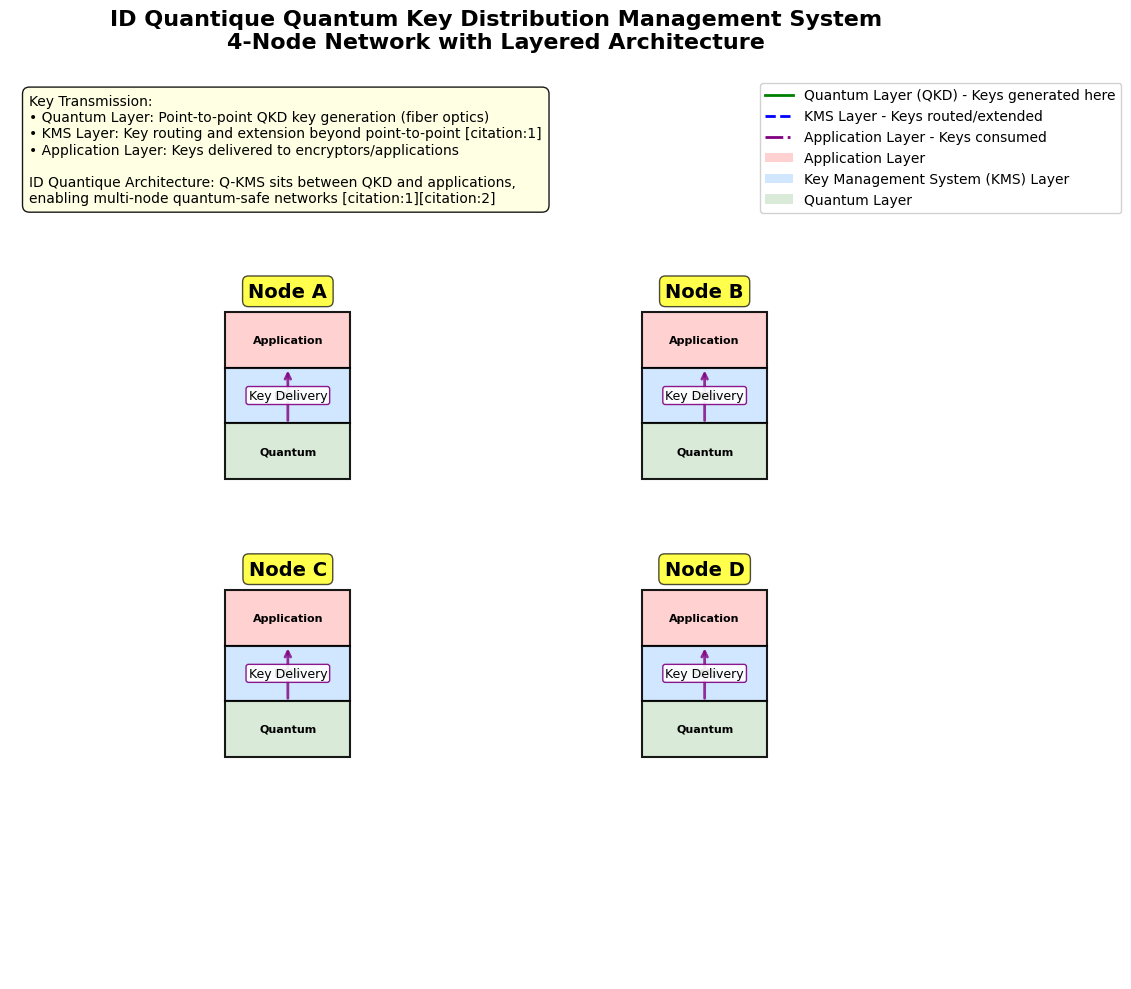

In [ ]:
#@title Draw a network
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import numpy as np

def draw_qkd_node(ax, x, y, label, node_id):
    """Draw a QKD node with three layers: Application, KMS, Quantum"""

    # Layer dimensions
    layer_height = 0.8
    total_height = layer_height * 3
    width = 1.8

    # Colors for different layers
    colors = {
        'app': '#ffcccc',  # Light red for Application Layer
        'kms': '#cce5ff',  # Light blue for KMS Layer
        'quantum': '#d5e8d4'  # Light green for Quantum Layer
    }

    # Draw the three layers stacked vertically
    # Application Layer (top)
    app_rect = patches.Rectangle((x - width/2, y + layer_height), width, layer_height,
                                 linewidth=1.5, edgecolor='black', facecolor=colors['app'], alpha=0.9)
    ax.add_patch(app_rect)
    ax.text(x, y + layer_height + layer_height/2, 'Application', ha='center', va='center', fontsize=8, fontweight='bold')

    # KMS Layer (middle)
    kms_rect = patches.Rectangle((x - width/2, y), width, layer_height,
                                linewidth=1.5, edgecolor='black', facecolor=colors['kms'], alpha=0.9)
    ax.add_patch(kms_rect)
    ax.text(x, y + layer_height/2, 'KMS', ha='center', va='center', fontsize=8, fontweight='bold')

    # Quantum Layer (bottom)
    quantum_rect = patches.Rectangle((x - width/2, y - layer_height), width, layer_height,
                                    linewidth=1.5, edgecolor='black', facecolor=colors['quantum'], alpha=0.9)
    ax.add_patch(quantum_rect)
    ax.text(x, y - layer_height/2, 'Quantum', ha='center', va='center', fontsize=8, fontweight='bold')

    # Node label (A, B, C, D)
    ax.text(x, y + layer_height*2 + 0.3, f'Node {node_id}', ha='center', va='center',
            fontsize=14, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

def draw_key_transmission(ax, start_pos, end_pos, layer, linestyle='-', color='red', label=''):
    """Draw key transmission between layers of different nodes"""
    x1, y1 = start_pos
    x2, y2 = end_pos

    # Add arrow to show direction of key flow
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, linestyle=linestyle, linewidth=2, alpha=0.8))

    # Add label at midpoint if provided
    if label:
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2
        ax.text(mid_x, mid_y, label, ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor=color, alpha=0.9))

def draw_qkd_network():
    """Draw a 4-node QKD management system based on ID Quantique architecture"""

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_xlim(-2, 12)
    ax.set_ylim(-3, 10)
    ax.set_aspect('equal')
    ax.axis('off')

    # Node positions (arranged in a square for 4 nodes)
    # Each node has coordinates for its center (KMS layer center)
    node_positions = {
        'A': (2, 5),
        'B': (8, 5),
        'C': (2, 1),
        'D': (8, 1)
    }

    # Draw the four nodes with their three layers
    for node_id, (x, y) in node_positions.items():
        draw_qkd_node(ax, x, y, f'Node {node_id}', node_id)

    # Calculate layer positions for each node
    # For each node: Quantum layer at y-0.8, KMS at y, Application at y+0.8
    layer_positions = {}
    for node_id, (x, y) in node_positions.items():
        layer_positions[node_id] = {
            'quantum': (x, y - 0.8),
            'kms': (x, y),
            'app': (x, y + 0.8)
        }

    # Draw Quantum Layer connections (point-to-point QKD links)
    # These are the physical layer where quantum keys are generated

    '''
    # Connect A quantum to B quantum
    draw_key_transmission(ax, layer_positions['A']['quantum'], layer_positions['B']['quantum'],
                         'quantum', '-', 'green', 'QKD Link')

    # Connect B quantum to D quantum
    draw_key_transmission(ax, layer_positions['B']['quantum'], layer_positions['D']['quantum'],
                         'quantum', '-', 'green', 'QKD Link')

    # Connect C quantum to D quantum
    draw_key_transmission(ax, layer_positions['C']['quantum'], layer_positions['D']['quantum'],
                         'quantum', '-', 'green', 'QKD Link')

    # Connect A quantum to C quantum
    draw_key_transmission(ax, layer_positions['A']['quantum'], layer_positions['C']['quantum'],
                         'quantum', '-', 'green', 'QKD Link')
    '''

    # Draw KMS Layer connections (key management and routing)
    # This layer extends QKD beyond point-to-point [citation:1]

    # KMS fully connects all nodes (key routing layer)
    '''
    draw_key_transmission(ax, layer_positions['A']['kms'], layer_positions['B']['kms'],
                         'kms', '--', 'blue', 'Key Routing')
    draw_key_transmission(ax, layer_positions['A']['kms'], layer_positions['C']['kms'],
                         'kms', '--', 'blue', 'Key Routing')
    draw_key_transmission(ax, layer_positions['A']['kms'], layer_positions['D']['kms'],
                         'kms', '--', 'blue', 'Key Routing')
    draw_key_transmission(ax, layer_positions['B']['kms'], layer_positions['C']['kms'],
                         'kms', '--', 'blue', 'Key Routing')
    draw_key_transmission(ax, layer_positions['B']['kms'], layer_positions['D']['kms'],
                         'kms', '--', 'blue', 'Key Routing')
    draw_key_transmission(ax, layer_positions['C']['kms'], layer_positions['D']['kms'],
                         'kms', '--', 'blue', 'Key Routing')
    '''

    # Draw Application Layer connections (key consumption)
    # Applications consume keys from the KMS layer [citation:1]

    draw_key_transmission(ax, layer_positions['A']['kms'], layer_positions['A']['app'],
                         'app', '-.', 'purple', 'Key Delivery')
    draw_key_transmission(ax, layer_positions['B']['kms'], layer_positions['B']['app'],
                         'app', '-.', 'purple', 'Key Delivery')
    draw_key_transmission(ax, layer_positions['C']['kms'], layer_positions['C']['app'],
                         'app', '-.', 'purple', 'Key Delivery')
    draw_key_transmission(ax, layer_positions['D']['kms'], layer_positions['D']['app'],
                         'app', '-.', 'purple', 'Key Delivery')

    # Add title and legend
    ax.set_title("ID Quantique Quantum Key Distribution Management System\n4-Node Network with Layered Architecture",
                fontsize=16, fontweight='bold', pad=20)

    # Create custom legend
    legend_elements = [
        mlines.Line2D([], [], color='green', linewidth=2, label='Quantum Layer (QKD) - Keys generated here'),
        mlines.Line2D([], [], color='blue', linestyle='--', linewidth=2, label='KMS Layer - Keys routed/extended'),
        mlines.Line2D([], [], color='purple', linestyle='-.', linewidth=2, label='Application Layer - Keys consumed'),
        patches.Patch(facecolor='#ffcccc', alpha=0.9, label='Application Layer'),
        patches.Patch(facecolor='#cce5ff', alpha=0.9, label='Key Management System (KMS) Layer'),
        patches.Patch(facecolor='#d5e8d4', alpha=0.9, label='Quantum Layer')
    ]

    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1),
             fontsize=10, framealpha=0.9)

    # Add explanatory text box
    explanation = (
        "Key Transmission:\n"
        "• Quantum Layer: Point-to-point QKD key generation (fiber optics)\n"
        "• KMS Layer: Key routing and extension beyond point-to-point [citation:1]\n"
        "• Application Layer: Keys delivered to encryptors/applications\n\n"
        "ID Quantique Architecture: Q-KMS sits between QKD and applications,\n"
        "enabling multi-node quantum-safe networks [citation:1][citation:2]"
    )

    ax.text(0.02, 0.98, explanation, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.9))

    plt.tight_layout()
    plt.show()

def main():
    """Main function to run the QKD network visualization"""
    print("ID Quantique QKD Management System - 4-Node Network Visualization")
    print("=" * 60)
    print("This diagram shows a 4-node quantum network with layered architecture:")
    print("  • Nodes A, B, C, D each contain three layers")
    print("  • Quantum Layer (bottom): Point-to-point QKD key generation [citation:3]")
    print("  • KMS Layer (middle): Key routing and network extension [citation:1]")
    print("  • Application Layer (top): Key consumption by encryptors")
    print("\nThe Quantum Key Management System (Q-KMS) acts as the 'glue'")
    print("between QKD systems and applications, enabling multi-node networks [citation:1][citation:2]")
    print("\nDrawing network diagram...")

    draw_qkd_network()

if __name__ == "__main__":
    main()